# Phase 2: CNN Training for MLN Severity Classification

## Project Overview

This notebook implements a deep learning model for classifying Maize Lethal Necrosis (MLN) disease severity into three categories: Early, Moderate, and Severe. The approach is based on transfer learning using pre-trained convolutional neural networks, following methodologies from plant disease classification research in East Africa.

## Target Accuracy: 85%+

## Methodology

1. **Data Preparation**: Load, validate, and preprocess the labeled dataset
2. **Data Augmentation**: Apply domain-specific augmentations for plant disease images
3. **Model Architecture**: Transfer learning with ResNet50V2 (proven effective for plant disease classification)
4. **Two-Stage Training**: 
   - Stage 1: Train classifier head with frozen base
   - Stage 2: Fine-tune with unfrozen layers and lower learning rate
5. **Evaluation**: Comprehensive metrics including confusion matrix and per-class analysis

## Key Improvements Over Previous Approaches

- Use of model-specific preprocessing (not generic rescale=1./255)
- Two-stage training strategy for better convergence
- Focal loss for handling class imbalance
- Cosine annealing learning rate schedule
- Proper data validation and cleaning

## Section 1: Environment Setup and Imports

Import all required libraries for data processing, model building, training, and evaluation. Configure GPU memory growth to prevent out-of-memory errors.

In [1]:
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================

import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2, EfficientNetB0
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
import json
import os
import pickle
import math
import warnings
from pathlib import Path

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# GPU Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU available: {[gpu.name for gpu in gpus]}")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("No GPU found, using CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {SEED}")

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

2026-02-16 10:18:30.870875: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


No GPU found, using CPU
TensorFlow version: 2.14.0
Random seed: 42


## Section 2: Configuration and Hyperparameters

Define all configurable parameters in one place for easy experimentation. This allows quick adjustments without modifying code throughout the notebook.

In [3]:
# =============================================================================
# CONFIGURATION - Modify these parameters to experiment
# =============================================================================

class Config:
    """Central configuration class for all hyperparameters."""
    
    # Paths
    DATA_DIR = '../mln_labels_v2'
    LABELS_PATH = '../scripts/Phase1_labeling/mln_severity_labels_v2.json'
    OUTPUT_DIR = '../models'
    
    # Image parameters
    IMG_SIZE = 224
    CHANNELS = 3
    INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, CHANNELS)
    
    # Training parameters
    BATCH_SIZE = 32
    EPOCHS_STAGE1 = 20      # Frozen base training
    EPOCHS_STAGE2 = 40      # Fine-tuning
    VALIDATION_SPLIT = 0.2
    
    # Learning rates
    LR_STAGE1 = 1e-3        # Higher LR for classifier head
    LR_STAGE2 = 1e-5        # Lower LR for fine-tuning
    MIN_LR = 1e-7
    
    # Model architecture
    BASE_MODEL = 'ResNet50V2'  # Options: 'ResNet50V2', 'EfficientNetB0'
    UNFREEZE_LAYERS = 50       # Number of layers to unfreeze in Stage 2
    DENSE_UNITS = 256
    DROPOUT_RATE = 0.5
    L2_REGULARIZATION = 0.01
    
    # Augmentation parameters
    ROTATION_RANGE = 40
    WIDTH_SHIFT = 0.3
    HEIGHT_SHIFT = 0.3
    ZOOM_RANGE = 0.3
    BRIGHTNESS_RANGE = (0.6, 1.4)
    
    # Focal loss parameters
    FOCAL_GAMMA = 2.0
    FOCAL_ALPHA = 0.25
    
    # Class names
    CLASS_NAMES = ['Early', 'Moderate', 'Severe']
    NUM_CLASSES = len(CLASS_NAMES)
    
    # Random seed
    SEED = 42

# Create config instance
config = Config()

# Print configuration
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
print(f"Data Directory:     {config.DATA_DIR}")
print(f"Image Size:         {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Batch Size:         {config.BATCH_SIZE}")
print(f"Base Model:         {config.BASE_MODEL}")
print(f"Stage 1 Epochs:     {config.EPOCHS_STAGE1}")
print(f"Stage 2 Epochs:     {config.EPOCHS_STAGE2}")
print(f"Stage 1 LR:         {config.LR_STAGE1}")
print(f"Stage 2 LR:         {config.LR_STAGE2}")
print("=" * 60)

CONFIGURATION
Data Directory:     ../mln_labels_v2
Image Size:         224x224
Batch Size:         32
Base Model:         ResNet50V2
Stage 1 Epochs:     20
Stage 2 Epochs:     40
Stage 1 LR:         0.001
Stage 2 LR:         1e-05


## Section 3: Utility Functions

Define reusable functions for data loading, validation, visualization, and model building. These functions are parameterized to allow easy experimentation with different configurations.

In [4]:
# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

def validate_image(image_path, min_size=50):
    """
    Validate that an image file is readable and meets minimum size requirements.
    
    Args:
        image_path: Path to the image file
        min_size: Minimum dimension size in pixels
        
    Returns:
        tuple: (is_valid, error_message)
    """
    try:
        with Image.open(image_path) as img:
            img.verify()
        with Image.open(image_path) as img:
            width, height = img.size
            if width < min_size or height < min_size:
                return False, f"Image too small: {width}x{height}"
            if img.mode not in ['RGB', 'L']:
                img = img.convert('RGB')
        return True, None
    except Exception as e:
        return False, str(e)


def scan_dataset(data_dir, class_names=None):
    """
    Scan dataset directory and validate all images.
    
    Args:
        data_dir: Root directory containing class subdirectories
        class_names: List of expected class names (optional)
        
    Returns:
        dict: Statistics about the dataset
    """
    stats = {
        'total_images': 0,
        'valid_images': 0,
        'invalid_images': 0,
        'class_counts': {},
        'invalid_files': []
    }
    
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
            
        if class_names and class_name not in class_names:
            print(f"Warning: Unexpected class directory: {class_name}")
            continue
        
        valid_count = 0
        for filename in os.listdir(class_path):
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                continue
                
            stats['total_images'] += 1
            image_path = os.path.join(class_path, filename)
            
            is_valid, error = validate_image(image_path)
            if is_valid:
                valid_count += 1
                stats['valid_images'] += 1
            else:
                stats['invalid_images'] += 1
                stats['invalid_files'].append((image_path, error))
        
        stats['class_counts'][class_name] = valid_count
    
    return stats


def compute_class_weights(generator):
    """
    Compute balanced class weights from a data generator.
    
    Args:
        generator: Keras ImageDataGenerator flow object
        
    Returns:
        dict: Class index to weight mapping
    """
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(generator.classes),
        y=generator.classes
    )
    return dict(enumerate(class_weights))


def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss for handling class imbalance.
    
    Focal loss down-weights easy examples and focuses training on hard negatives.
    Reference: Lin et al., "Focal Loss for Dense Object Detection", ICCV 2017
    
    Args:
        gamma: Focusing parameter (higher = more focus on hard examples)
        alpha: Balancing parameter
        
    Returns:
        Loss function
    """
    def focal_loss_fn(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        
        cross_entropy = -y_true * K.log(y_pred)
        focal_weight = K.pow(1 - y_pred, gamma)
        loss = alpha * focal_weight * cross_entropy
        
        return K.sum(loss, axis=-1)
    
    return focal_loss_fn


def cosine_annealing_schedule(epoch, initial_lr, total_epochs, warmup_epochs=5, min_lr=1e-7):
    """
    Cosine annealing learning rate schedule with warm-up.
    
    Args:
        epoch: Current epoch (0-indexed)
        initial_lr: Starting learning rate after warm-up
        total_epochs: Total number of training epochs
        warmup_epochs: Number of warm-up epochs
        min_lr: Minimum learning rate
        
    Returns:
        Learning rate for the current epoch
    """
    if epoch < warmup_epochs:
        return initial_lr * (epoch + 1) / warmup_epochs
    
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + 0.5 * (initial_lr - min_lr) * (1 + math.cos(math.pi * progress))


print("Utility functions defined successfully")

Utility functions defined successfully


## Section 4: Visualization Functions

Define reusable plotting functions for data exploration, training monitoring, and model evaluation.

In [5]:
# =============================================================================
# VISUALIZATION FUNCTIONS
# =============================================================================

def plot_class_distribution(class_counts, title="Class Distribution"):
    """
    Plot class distribution as bar chart and pie chart.
    
    Args:
        class_counts: Dictionary or Series with class names and counts
        title: Plot title
    """
    if isinstance(class_counts, dict):
        class_counts = pd.Series(class_counts)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
    
    # Bar plot
    class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_title(f'{title} - Counts', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Severity Class', fontsize=12)
    axes[0].set_ylabel('Number of Images', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0)
    
    # Add count labels on bars
    for i, (idx, val) in enumerate(class_counts.items()):
        axes[0].text(i, val + 10, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Pie chart
    axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
                colors=colors, explode=[0.02]*len(class_counts), shadow=True)
    axes[1].set_title(f'{title} - Percentage', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_sample_images(generator, num_samples=9, class_names=None):
    """
    Display sample images from each class.
    
    Args:
        generator: Keras ImageDataGenerator flow object
        num_samples: Number of images to display per class
        class_names: List of class names
    """
    if class_names is None:
        class_names = list(generator.class_indices.keys())
    
    num_classes = len(class_names)
    cols = 3
    rows = num_classes
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows))
    
    # Get a batch
    batch_x, batch_y = next(generator)
    
    for class_idx, class_name in enumerate(class_names):
        # Find images of this class
        class_mask = np.argmax(batch_y, axis=1) == generator.class_indices[class_name]
        class_images = batch_x[class_mask]
        
        for j in range(min(cols, len(class_images))):
            ax = axes[class_idx, j] if rows > 1 else axes[j]
            
            # Denormalize for display
            img = class_images[j]
            if img.max() <= 1.0:
                img = (img * 255).astype(np.uint8)
            
            ax.imshow(img.astype(np.uint8))
            ax.set_title(f'{class_name}', fontsize=11)
            ax.axis('off')
    
    plt.suptitle('Sample Images by Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_training_history(history, save_path=None):
    """
    Plot training history: accuracy, loss, and learning rate.
    
    Args:
        history: Keras History object or dict
        save_path: Optional path to save the figure
        
    Returns:
        matplotlib Figure object
    """
    if hasattr(history, 'history'):
        history = history.history
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(history['accuracy']) + 1)
    
    # Accuracy plot
    axes[0].plot(epochs, history['accuracy'], 'b-', label='Training', linewidth=2, marker='o', markersize=4)
    axes[0].plot(epochs, history['val_accuracy'], 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
    axes[0].axhline(y=0.85, color='g', linestyle='--', label='Target (85%)', alpha=0.7, linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])
    
    # Loss plot
    axes[1].plot(epochs, history['loss'], 'b-', label='Training', linewidth=2, marker='o', markersize=4)
    axes[1].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # Learning rate plot
    if 'lr' in history:
        axes[2].plot(epochs, history['lr'], 'purple', linewidth=2, marker='d', markersize=4)
        axes[2].set_title('Learning Rate', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Epoch', fontsize=12)
        axes[2].set_ylabel('Learning Rate', fontsize=12)
        axes[2].set_yscale('log')
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'Learning rate\nnot recorded', ha='center', va='center', fontsize=12)
        axes[2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    return fig


def plot_confusion_matrix(y_true, y_pred, class_names, save_path=None):
    """
    Plot confusion matrix with raw counts and normalized percentages.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        class_names: List of class names
        save_path: Optional path to save the figure
        
    Returns:
        matplotlib Figure object
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0],
                annot_kws={'size': 14}, cbar_kws={'label': 'Count'})
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1],
                annot_kws={'size': 14}, cbar_kws={'label': 'Percentage'})
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
    
    return fig, cm, cm_normalized


def plot_confidence_distribution(confidence_scores, predictions, true_labels, class_names, save_path=None):
    """
    Plot confidence score distributions.
    
    Args:
        confidence_scores: Array of confidence scores
        predictions: Predicted class indices
        true_labels: True class indices
        class_names: List of class names
        save_path: Optional path to save figure
        
    Returns:
        matplotlib Figure object
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    correct_mask = predictions == true_labels
    
    # Correct vs Incorrect
    axes[0].hist(confidence_scores[correct_mask], bins=20, alpha=0.7, 
                 label=f'Correct (n={sum(correct_mask)})', color='#2ecc71', edgecolor='black')
    axes[0].hist(confidence_scores[~correct_mask], bins=20, alpha=0.7,
                 label=f'Incorrect (n={sum(~correct_mask)})', color='#e74c3c', edgecolor='black')
    axes[0].axvline(x=np.mean(confidence_scores), color='blue', linestyle='--',
                    label=f'Mean: {np.mean(confidence_scores):.3f}', linewidth=2)
    axes[0].set_title('Confidence: Correct vs Incorrect', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Confidence Score', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # By class
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    confidence_by_class = [confidence_scores[predictions == i] for i in range(len(class_names))]
    
    bp = axes[1].boxplot(confidence_by_class, labels=class_names, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_title('Confidence by Predicted Class', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Confidence Score', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    
    return fig


print("Visualization functions defined successfully")

Visualization functions defined successfully


## Section 5: Data Loading and Validation

Load the dataset, validate all images, and identify any corrupted or problematic files. This ensures clean data for training.

In [6]:
# =============================================================================
# DATA VALIDATION
# =============================================================================

print("Scanning dataset for validation...")
print("=" * 60)

# Validate dataset
dataset_stats = scan_dataset(config.DATA_DIR, config.CLASS_NAMES)

print(f"Total images found:    {dataset_stats['total_images']}")
print(f"Valid images:          {dataset_stats['valid_images']}")
print(f"Invalid images:        {dataset_stats['invalid_images']}")
print()
print("Class Distribution:")
print("-" * 40)

total = sum(dataset_stats['class_counts'].values())
for class_name in config.CLASS_NAMES:
    count = dataset_stats['class_counts'].get(class_name, 0)
    pct = (count / total * 100) if total > 0 else 0
    print(f"  {class_name:12s}: {count:5d} images ({pct:5.1f}%)")

print("-" * 40)
print(f"  {'Total':12s}: {total:5d} images")

# Report invalid files if any
if dataset_stats['invalid_files']:
    print(f"\nWarning: {len(dataset_stats['invalid_files'])} invalid files found:")
    for path, error in dataset_stats['invalid_files'][:5]:
        print(f"  - {os.path.basename(path)}: {error}")
    if len(dataset_stats['invalid_files']) > 5:
        print(f"  ... and {len(dataset_stats['invalid_files']) - 5} more")

print("=" * 60)

Scanning dataset for validation...
Total images found:    3231
Valid images:          3231
Invalid images:        0

Class Distribution:
----------------------------------------
  Early       :  1401 images ( 43.4%)
  Moderate    :   992 images ( 30.7%)
  Severe      :   838 images ( 25.9%)
----------------------------------------
  Total       :  3231 images


## Section 6: Visualize Class Distribution

Visualize the dataset distribution to understand class imbalance. This informs our class weighting strategy.

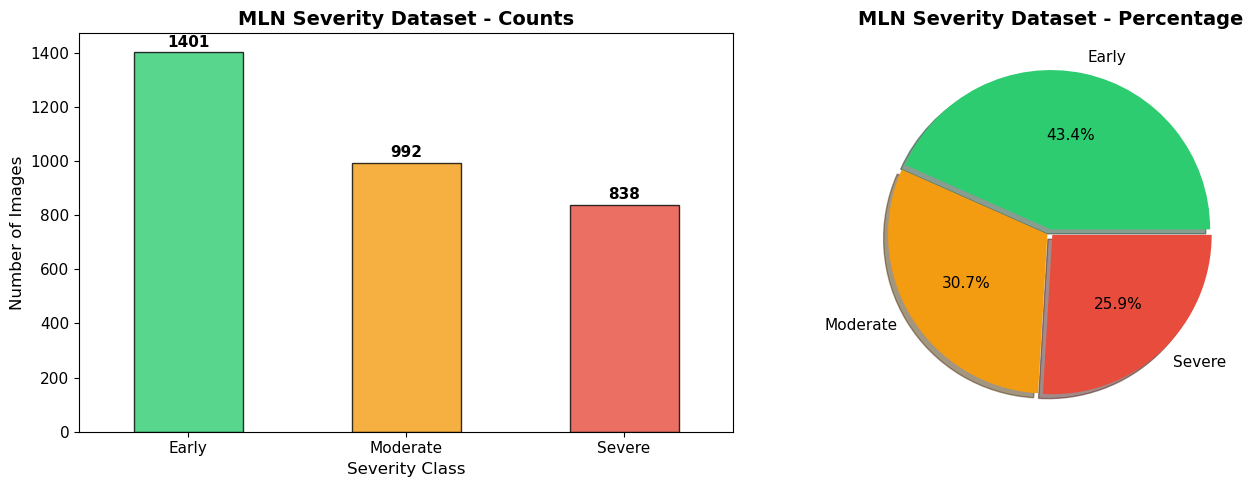

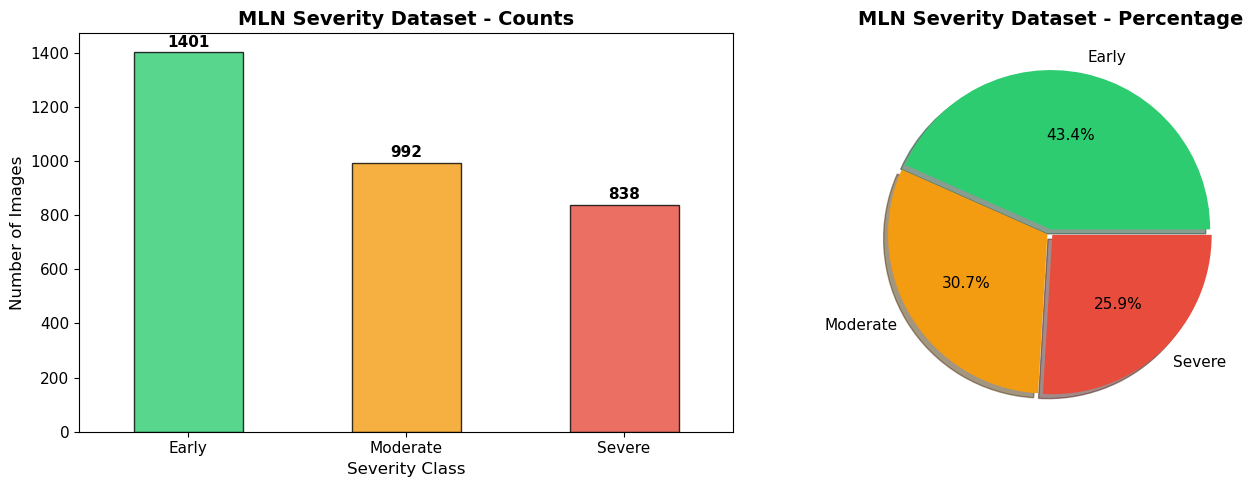

In [7]:
# =============================================================================
# VISUALIZE CLASS DISTRIBUTION
# =============================================================================

class_counts = pd.Series(dataset_stats['class_counts'])
class_counts = class_counts[config.CLASS_NAMES]  # Ensure correct order

plot_class_distribution(class_counts, title="MLN Severity Dataset")

## Section 7: Data Generators with Proper Preprocessing

Create data generators with model-specific preprocessing. This is critical - using the correct preprocessing function for the chosen base model significantly impacts performance.

Key points:
- ResNet50V2 expects preprocessing via `tensorflow.keras.applications.resnet_v2.preprocess_input`
- This normalizes pixel values to the range expected by the pre-trained model
- Data augmentation is applied only to training data

In [8]:
# =============================================================================
# DATA GENERATOR FACTORY
# =============================================================================

def create_data_generators(data_dir, config, preprocessing_function):
    """
    Create training and validation data generators.
    
    Args:
        data_dir: Path to data directory with class subdirectories
        config: Configuration object with augmentation parameters
        preprocessing_function: Model-specific preprocessing function
        
    Returns:
        tuple: (train_generator, val_generator)
    """
    # Training generator with augmentation
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocessing_function,
        rotation_range=config.ROTATION_RANGE,
        width_shift_range=config.WIDTH_SHIFT,
        height_shift_range=config.HEIGHT_SHIFT,
        shear_range=0.2,
        zoom_range=config.ZOOM_RANGE,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=config.BRIGHTNESS_RANGE,
        fill_mode='reflect',
        validation_split=config.VALIDATION_SPLIT
    )
    
    # Validation generator without augmentation
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocessing_function,
        validation_split=config.VALIDATION_SPLIT
    )
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=(config.IMG_SIZE, config.IMG_SIZE),
        batch_size=config.BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=config.SEED
    )
    
    val_generator = val_datagen.flow_from_directory(
        data_dir,
        target_size=(config.IMG_SIZE, config.IMG_SIZE),
        batch_size=config.BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=config.SEED
    )
    
    return train_generator, val_generator


# Create data generators with ResNet preprocessing
train_generator, val_generator = create_data_generators(
    config.DATA_DIR,
    config,
    resnet_preprocess
)

print("=" * 60)
print("DATA GENERATORS CREATED")
print("=" * 60)
print(f"Training samples:      {train_generator.samples}")
print(f"Validation samples:    {val_generator.samples}")
print(f"Batch size:            {config.BATCH_SIZE}")
print(f"Image size:            {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Classes:               {list(train_generator.class_indices.keys())}")
print(f"Preprocessing:         ResNet50V2 (preprocess_input)")
print("=" * 60)

Found 2587 images belonging to 3 classes.
Found 645 images belonging to 3 classes.
DATA GENERATORS CREATED
Training samples:      2587
Validation samples:    645
Batch size:            32
Image size:            224x224
Classes:               ['Early', 'Moderate', 'Severe']
Preprocessing:         ResNet50V2 (preprocess_input)


## Section 8: Compute Class Weights

Compute balanced class weights to handle any class imbalance. This ensures the model does not become biased toward the majority class.

In [9]:
# =============================================================================
# COMPUTE CLASS WEIGHTS
# =============================================================================

class_weight_dict = compute_class_weights(train_generator)
class_names_ordered = list(train_generator.class_indices.keys())
class_counts_train = np.bincount(train_generator.classes)

print("=" * 60)
print("CLASS WEIGHTS")
print("=" * 60)
print(f"{'Class':<12} {'Count':<8} {'Percentage':<12} {'Weight':<10}")
print("-" * 42)

for idx, name in enumerate(class_names_ordered):
    count = class_counts_train[idx]
    pct = count / len(train_generator.classes) * 100
    weight = class_weight_dict[idx]
    print(f"{name:<12} {count:<8} {pct:<12.1f} {weight:<10.4f}")

print("=" * 60)

CLASS WEIGHTS
Class        Count    Percentage   Weight    
------------------------------------------
Early        1121     43.3         0.7693    
Moderate     794      30.7         1.0861    
Severe       672      26.0         1.2832    


## Section 9: Model Architecture

Build the CNN model using transfer learning with ResNet50V2. The architecture follows proven approaches from plant disease classification research:

Architecture:
- Base: ResNet50V2 (pre-trained on ImageNet)
- Global Average Pooling (reduces overfitting vs Flatten)
- Batch Normalization (stabilizes training)
- Dropout (regularization)
- Dense layer with L2 regularization
- Softmax output for 3 classes

In [12]:
# =============================================================================
# SECTION 9: MODEL ARCHITECTURE
# =============================================================================

import os
from pathlib import Path

# -----------------------------------------------------------------------------
# Step 1: Clean up any corrupted cached weights
# -----------------------------------------------------------------------------
locations = [
    Path.home() / '.keras' / 'models',
    Path.home() / '.cache' / 'keras' / 'models'
]

weights_filename = 'resnet50v2_weights_tf_dim_ordering_tf_kernels_notop.h5'

for loc in locations:
    weights_path = loc / weights_filename
    if weights_path.exists():
        os.remove(weights_path)
        print(f"Deleted cached weights: {weights_path}")

# -----------------------------------------------------------------------------
# Step 2: Define model building function
# -----------------------------------------------------------------------------
def build_model(config, freeze_base=True):
    """
    Build transfer learning model with specified base architecture.
    
    Args:
        config: Configuration object with model parameters
        freeze_base: Whether to freeze base model layers (Stage 1)
        
    Returns:
        tuple: (model, base_model)
    """
    # Load pre-trained base model
    if config.BASE_MODEL == 'ResNet50V2':
        base_model = ResNet50V2(
            weights='imagenet',
            include_top=False,
            input_shape=config.INPUT_SHAPE
        )
    elif config.BASE_MODEL == 'EfficientNetB0':
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=config.INPUT_SHAPE
        )
    else:
        raise ValueError(f"Unknown base model: {config.BASE_MODEL}")
    
    # Freeze base model for Stage 1
    base_model.trainable = not freeze_base
    
    # Build classifier head
    inputs = Input(shape=config.INPUT_SHAPE)
    
    # Pass through base model
    x = base_model(inputs, training=False)
    
    # Global Average Pooling
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    
    # Batch Normalization
    x = BatchNormalization(name='batch_norm')(x)
    
    # Dropout for regularization
    x = Dropout(config.DROPOUT_RATE, name='dropout_1')(x)
    
    # Dense layer with L2 regularization
    x = Dense(
        config.DENSE_UNITS,
        activation='relu',
        kernel_regularizer=regularizers.l2(config.L2_REGULARIZATION),
        name='dense_1'
    )(x)
    
    # Additional dropout
    x = Dropout(config.DROPOUT_RATE * 0.6, name='dropout_2')(x)
    
    # Output layer
    outputs = Dense(
        config.NUM_CLASSES,
        activation='softmax',
        name='predictions'
    )(x)
    
    # Create model
    model = Model(inputs, outputs, name=f'MLN_{config.BASE_MODEL}_Classifier')
    
    return model, base_model


def unfreeze_model(model, base_model, num_layers_to_unfreeze):
    """
    Unfreeze the top N layers of the base model for fine-tuning.
    
    Args:
        model: Full Keras model
        base_model: Base model (e.g., ResNet50V2)
        num_layers_to_unfreeze: Number of layers to unfreeze from the top
        
    Returns:
        tuple: (frozen_count, trainable_count)
    """
    # Make base model trainable
    base_model.trainable = True
    
    # Freeze all layers except the top N
    total_layers = len(base_model.layers)
    freeze_until = total_layers - num_layers_to_unfreeze
    
    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False
    
    # Count frozen and trainable layers
    frozen = sum(1 for layer in base_model.layers if not layer.trainable)
    trainable = sum(1 for layer in base_model.layers if layer.trainable)
    
    return frozen, trainable


# -----------------------------------------------------------------------------
# Step 3: Build the model (Stage 1: frozen base)
# -----------------------------------------------------------------------------
print("Building model...")
model, base_model = build_model(config, freeze_base=True)

# Print model summary
print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
print(f"Base Model:            {config.BASE_MODEL}")
print(f"Base Model Layers:     {len(base_model.layers)}")
print(f"Base Model Trainable:  {base_model.trainable}")
print(f"Input Shape:           {config.INPUT_SHAPE}")
print(f"Output Classes:        {config.NUM_CLASSES}")
print(f"Dense Units:           {config.DENSE_UNITS}")
print(f"Dropout Rate:          {config.DROPOUT_RATE}")
print(f"L2 Regularization:     {config.L2_REGULARIZATION}")
print()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"Total Parameters:      {total_params:,}")
print(f"Trainable Parameters:  {trainable_params:,}")
print(f"Non-trainable Params:  {non_trainable_params:,}")
print("=" * 60)


Building model...
94668760/94668760 [==============================] - 39s 0us/step
MODEL ARCHITECTURE
Base Model:            ResNet50V2
Base Model Layers:     190
Base Model Trainable:  False
Input Shape:           (224, 224, 3)
Output Classes:        3
Dense Units:           256
Dropout Rate:          0.5
L2 Regularization:     0.01

Total Parameters:      24,098,307
Trainable Parameters:  529,411
Non-trainable Params:  23,568,896


## Section 10: Training Callbacks

Define callbacks for training control:
- EarlyStopping: Stop when validation accuracy stops improving
- ReduceLROnPlateau: Reduce learning rate when loss plateaus
- ModelCheckpoint: Save best model based on validation accuracy

In [14]:
# =============================================================================
# CALLBACK FACTORY
# =============================================================================

def create_callbacks(stage, config, checkpoint_path='best_model.h5'):
    """
    Create training callbacks for a given stage.
    
    Args:
        stage: Training stage (1 or 2)
        config: Configuration object
        checkpoint_path: Path to save best model
        
    Returns:
        list: List of callback objects
    """
    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=10 if stage == 1 else 15,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5 if stage == 1 else 7,
            min_lr=config.MIN_LR,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    return callbacks


# Create callbacks for Stage 1
callbacks_stage1 = create_callbacks(stage=1, config=config, checkpoint_path='best_model_stage1.h5')

print("Callbacks configured for Stage 1:")
for cb in callbacks_stage1:
    print(f"  - {cb.__class__.__name__}")

Callbacks configured for Stage 1:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


## Section 11: Stage 1 Training - Classifier Head Only

In Stage 1, we train only the classifier head while keeping the base model frozen. This allows the classifier to adapt to our specific classes without destroying the pre-trained features.

- Higher learning rate (1e-3) since we are only training the head
- Categorical crossentropy loss
- Class weights for imbalance handling

In [16]:
# =============================================================================
# STAGE 1: TRAIN CLASSIFIER HEAD
# =============================================================================

# Compile model for Stage 1
model.compile(
    optimizer=Adam(learning_rate=config.LR_STAGE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print("STAGE 1: TRAINING CLASSIFIER HEAD (Base Frozen)")
print("=" * 60)
print(f"Learning rate:         {config.LR_STAGE1}")
print(f"Epochs:                {config.EPOCHS_STAGE1}")
print(f"Training samples:      {train_generator.samples}")
print(f"Validation samples:    {val_generator.samples}")
print(f"Steps per epoch:       {len(train_generator)}")
print("=" * 60)

# Reset generators
train_generator.reset()
val_generator.reset()

# Train Stage 1
history_stage1 = model.fit(
    train_generator,
    epochs=config.EPOCHS_STAGE1,
    validation_data=val_generator,
    callbacks=callbacks_stage1,
    class_weight=class_weight_dict,
    verbose=1
)

# Report results
best_val_acc_s1 = max(history_stage1.history['val_accuracy'])
best_epoch_s1 = history_stage1.history['val_accuracy'].index(best_val_acc_s1) + 1

print()
print("=" * 60)
print("STAGE 1 COMPLETE")
print("=" * 60)
print(f"Best Validation Accuracy: {best_val_acc_s1:.4f} ({best_val_acc_s1*100:.1f}%)")
print(f"Achieved at Epoch:        {best_epoch_s1}")
print("=" * 60)

STAGE 1: TRAINING CLASSIFIER HEAD (Base Frozen)
Learning rate:         0.001
Epochs:                20
Training samples:      2587
Validation samples:    645
Steps per epoch:       81
Epoch 1/20
81/81 [==============================] - ETA: 0s - loss: 5.1037 - accuracy: 0.4828
Epoch 1: val_accuracy improved from -inf to 0.55814, saving model to best_model_stage1.h5
81/81 [==============================] - 255s 3s/step - loss: 5.1037 - accuracy: 0.4828 - val_loss: 3.9047 - val_accuracy: 0.5581 - lr: 0.0010
Epoch 2/20
81/81 [==============================] - ETA: 0s - loss: 3.9569 - accuracy: 0.5435
Epoch 2: val_accuracy improved from 0.55814 to 0.59535, saving model to best_model_stage1.h5
81/81 [==============================] - 281s 3s/step - loss: 3.9569 - accuracy: 0.5435 - val_loss: 3.2291 - val_accuracy: 0.5953 - lr: 0.0010
Epoch 3/20
81/81 [==============================] - ETA: 0s - loss: 3.1789 - accuracy: 0.5651
Epoch 3: val_accuracy did not improve from 0.59535
81/81 [=======

In [15]:
## Section 12: Stage 2 Training - Fine-Tuning

In Stage 2, we unfreeze the top layers of the base model and fine-tune the entire network with a much lower learning rate. This allows the model to adapt the pre-trained features to our specific domain (plant disease images).

Key considerations:
- Lower learning rate (1e-5) to avoid destroying pre-trained features
- Unfreeze only the top N layers (gradual unfreezing)
- Cosine annealing schedule for optimal convergence
- Focal loss for better handling of class imbalance

SyntaxError: invalid syntax (1129467065.py, line 3)

In [17]:
# =============================================================================
# STAGE 2: FINE-TUNING WITH UNFROZEN LAYERS
# =============================================================================

# Unfreeze top layers of base model
frozen_count, trainable_count = unfreeze_model(
    model, base_model, config.UNFREEZE_LAYERS
)

print("=" * 60)
print("STAGE 2: FINE-TUNING (Partial Unfreeze)")
print("=" * 60)
print(f"Base model layers:     {len(base_model.layers)}")
print(f"Frozen layers:         {frozen_count}")
print(f"Unfrozen layers:       {trainable_count}")
print()

# Create learning rate scheduler
def lr_schedule(epoch):
    return cosine_annealing_schedule(
        epoch, 
        config.LR_STAGE2, 
        config.EPOCHS_STAGE2,
        warmup_epochs=3,
        min_lr=config.MIN_LR
    )

# Create callbacks for Stage 2
callbacks_stage2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    LearningRateScheduler(lr_schedule, verbose=1),
    ModelCheckpoint(
        'best_model_final.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=config.LR_STAGE2),
    loss=focal_loss(gamma=config.FOCAL_GAMMA, alpha=config.FOCAL_ALPHA),
    metrics=['accuracy']
)

print(f"Learning rate:         {config.LR_STAGE2}")
print(f"Loss function:         Focal Loss (gamma={config.FOCAL_GAMMA})")
print(f"Epochs:                {config.EPOCHS_STAGE2}")
print("=" * 60)

# Reset generators
train_generator.reset()
val_generator.reset()

# Train Stage 2
history_stage2 = model.fit(
    train_generator,
    epochs=config.EPOCHS_STAGE2,
    validation_data=val_generator,
    callbacks=callbacks_stage2,
    class_weight=class_weight_dict,
    verbose=1
)

# Report results
best_val_acc_s2 = max(history_stage2.history['val_accuracy'])
best_epoch_s2 = history_stage2.history['val_accuracy'].index(best_val_acc_s2) + 1

print()
print("=" * 60)
print("STAGE 2 COMPLETE")
print("=" * 60)
print(f"Best Validation Accuracy: {best_val_acc_s2:.4f} ({best_val_acc_s2*100:.1f}%)")
print(f"Achieved at Epoch:        {best_epoch_s2}")
print(f"Target (85%):             {'ACHIEVED' if best_val_acc_s2 >= 0.85 else 'Not yet'}")
print("=" * 60)

STAGE 2: FINE-TUNING (Partial Unfreeze)
Base model layers:     190
Frozen layers:         140
Unfrozen layers:       50

Learning rate:         1e-05
Loss function:         Focal Loss (gamma=2.0)
Epochs:                40

Epoch 1: LearningRateScheduler setting learning rate to 3.3333333333333337e-06.
Epoch 1/40
81/81 [==============================] - ETA: 0s - loss: 0.3224 - accuracy: 0.6119
Epoch 1: val_accuracy improved from -inf to 0.61240, saving model to best_model_final.h5
81/81 [==============================] - 271s 3s/step - loss: 0.3224 - accuracy: 0.6119 - val_loss: 0.3089 - val_accuracy: 0.6124 - lr: 3.3333e-06

Epoch 2: LearningRateScheduler setting learning rate to 6.6666666666666675e-06.
Epoch 2/40
81/81 [==============================] - ETA: 0s - loss: 0.3156 - accuracy: 0.6196
Epoch 2: val_accuracy improved from 0.61240 to 0.61705, saving model to best_model_final.h5
81/81 [==============================] - 278s 3s/step - loss: 0.3156 - accuracy: 0.6196 - val_loss: 

In [ ]:
## Section 13: Combine Training History

Combine history from both training stages for complete visualization and analysis.

Training History Visualization:
Figure saved to: training_history.png


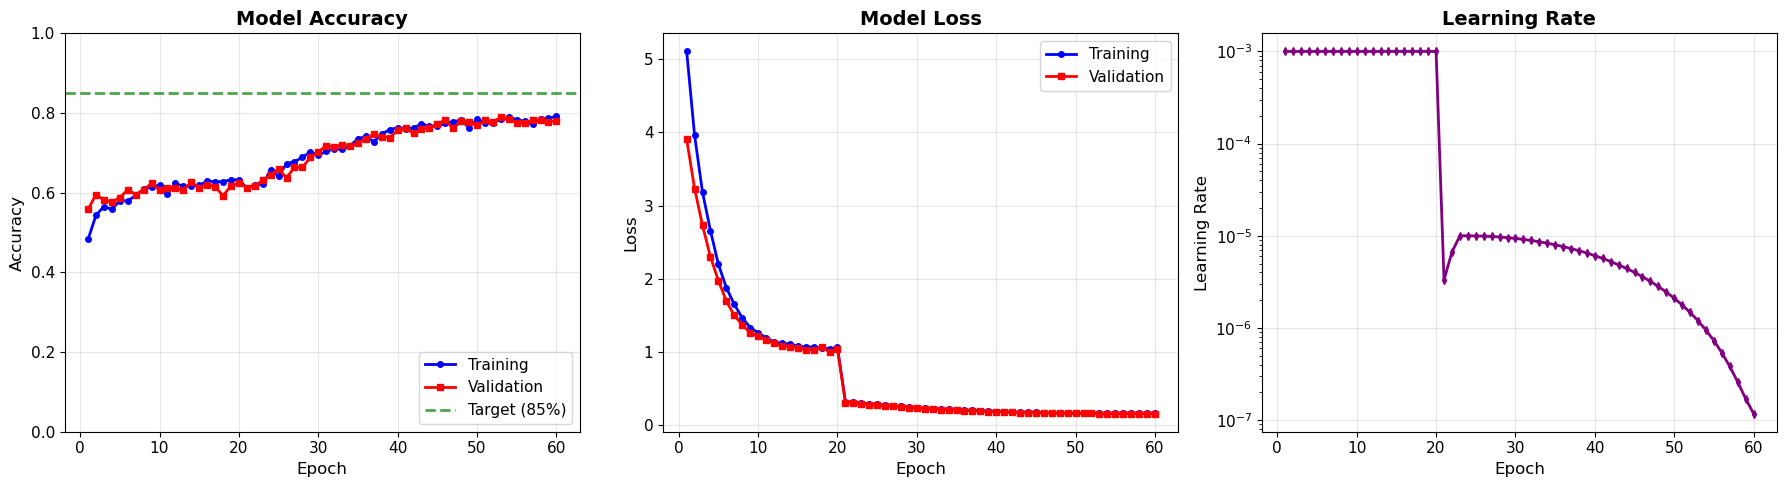


TRAINING SUMMARY
Total epochs trained:     60
Stage 1 epochs:           20
Stage 2 epochs:           40

Stage 1 best val acc:     62.6%
Stage 2 best val acc:     78.9%
Overall best val acc:     78.9%


In [18]:
# =============================================================================
# COMBINE TRAINING HISTORY
# =============================================================================

def combine_histories(history1, history2):
    """
    Combine two training history objects.
    
    Args:
        history1: First history (Stage 1)
        history2: Second history (Stage 2)
        
    Returns:
        dict: Combined history
    """
    combined = {}
    
    h1 = history1.history if hasattr(history1, 'history') else history1
    h2 = history2.history if hasattr(history2, 'history') else history2
    
    for key in h1.keys():
        combined[key] = h1[key] + h2.get(key, [])
    
    return combined


# Combine histories
combined_history = combine_histories(history_stage1, history_stage2)

# Plot combined training history
print("Training History Visualization:")
plot_training_history(combined_history, save_path='training_history.png')

# Print summary statistics
print()
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total epochs trained:     {len(combined_history['accuracy'])}")
print(f"Stage 1 epochs:           {len(history_stage1.history['accuracy'])}")
print(f"Stage 2 epochs:           {len(history_stage2.history['accuracy'])}")
print()
print(f"Stage 1 best val acc:     {best_val_acc_s1*100:.1f}%")
print(f"Stage 2 best val acc:     {best_val_acc_s2*100:.1f}%")
print(f"Overall best val acc:     {max(combined_history['val_accuracy'])*100:.1f}%")
print("=" * 60)

## Section 14: Model Evaluation

Load the best model and evaluate on the validation set. Generate predictions and compute comprehensive metrics.

In [19]:
# =============================================================================
# MODEL EVALUATION
# =============================================================================

# Load best model
from tensorflow.keras.models import load_model

# Custom objects for loading model with focal loss
custom_objects = {'focal_loss_fn': focal_loss(config.FOCAL_GAMMA, config.FOCAL_ALPHA)}

try:
    model = load_model('best_model_final.h5', custom_objects=custom_objects)
    print("Loaded best model from Stage 2 checkpoint")
except:
    print("Using current model (checkpoint may not exist)")

# Evaluate on validation set
val_generator.reset()
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)

print("=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)
print(f"Accuracy:    {val_accuracy:.4f} ({val_accuracy*100:.1f}%)")
print(f"Loss:        {val_loss:.4f}")
print(f"Target 85%:  {'ACHIEVED' if val_accuracy >= 0.85 else 'Not achieved'}")
print("=" * 60)

# Generate predictions
val_generator.reset()
predictions = model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
confidence_scores = np.max(predictions, axis=1)

# Get class names
class_names = list(val_generator.class_indices.keys())

# Classification Report
print()
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(true_classes, predicted_classes, 
                          target_names=class_names, digits=4))

Loaded best model from Stage 2 checkpoint
VALIDATION RESULTS
Accuracy:    0.7891 (78.9%)
Loss:        0.1607
Target 85%:  Not achieved
21/21 [==============================] - 41s 2s/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Early     0.8306    0.8929    0.8606       280
    Moderate     0.6970    0.6970    0.6970       198
      Severe     0.8288    0.7246    0.7732       167

    accuracy                         0.7891       645
   macro avg     0.7854    0.7715    0.7769       645
weighted avg     0.7891    0.7891    0.7877       645



## Section 15: Confusion Matrix and Per-Class Analysis

Visualize the confusion matrix to understand model performance across classes. This reveals which classes are being confused with each other.

Figure saved to: confusion_matrix.png


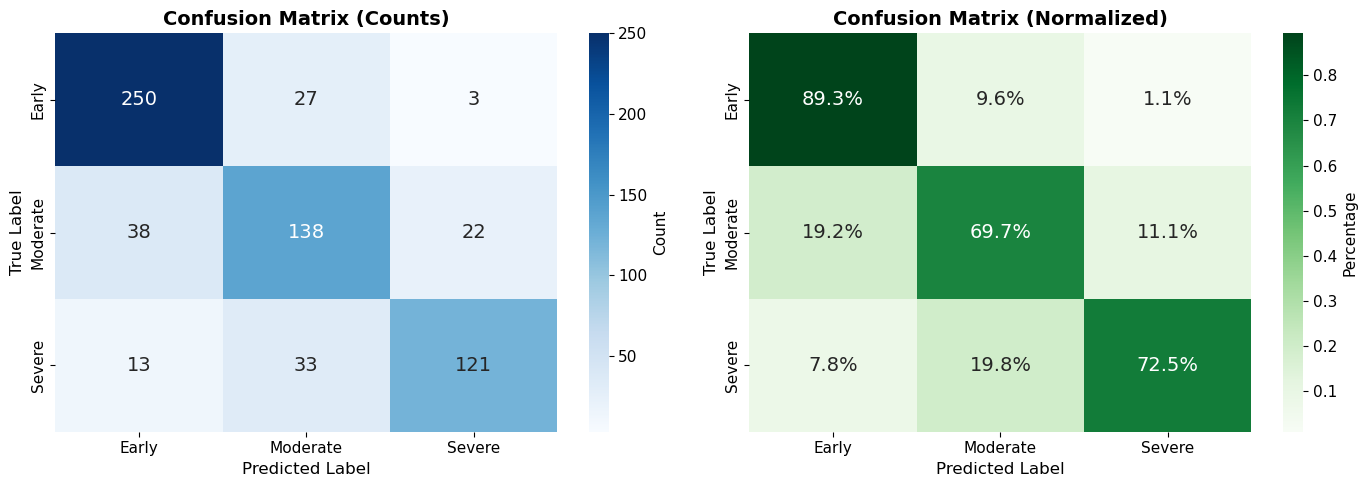


PER-CLASS ACCURACY
Class        Accuracy     Correct    Total     
--------------------------------------------
Early        89.3         250        280       
Moderate     69.7         138        198       
Severe       72.5         121        167       


In [20]:
# =============================================================================
# CONFUSION MATRIX
# =============================================================================

fig, cm, cm_normalized = plot_confusion_matrix(
    true_classes, 
    predicted_classes, 
    class_names,
    save_path='confusion_matrix.png'
)

# Per-class accuracy
print()
print("=" * 60)
print("PER-CLASS ACCURACY")
print("=" * 60)
print(f"{'Class':<12} {'Accuracy':<12} {'Correct':<10} {'Total':<10}")
print("-" * 44)

for i, class_name in enumerate(class_names):
    class_acc = cm_normalized[i, i]
    total = cm[i].sum()
    correct = cm[i, i]
    print(f"{class_name:<12} {class_acc*100:<12.1f} {correct:<10} {total:<10}")

print("=" * 60)

## Section 16: Confidence Score Analysis

Analyze the model's confidence in its predictions. High-confidence correct predictions and low-confidence incorrect predictions indicate a well-calibrated model.

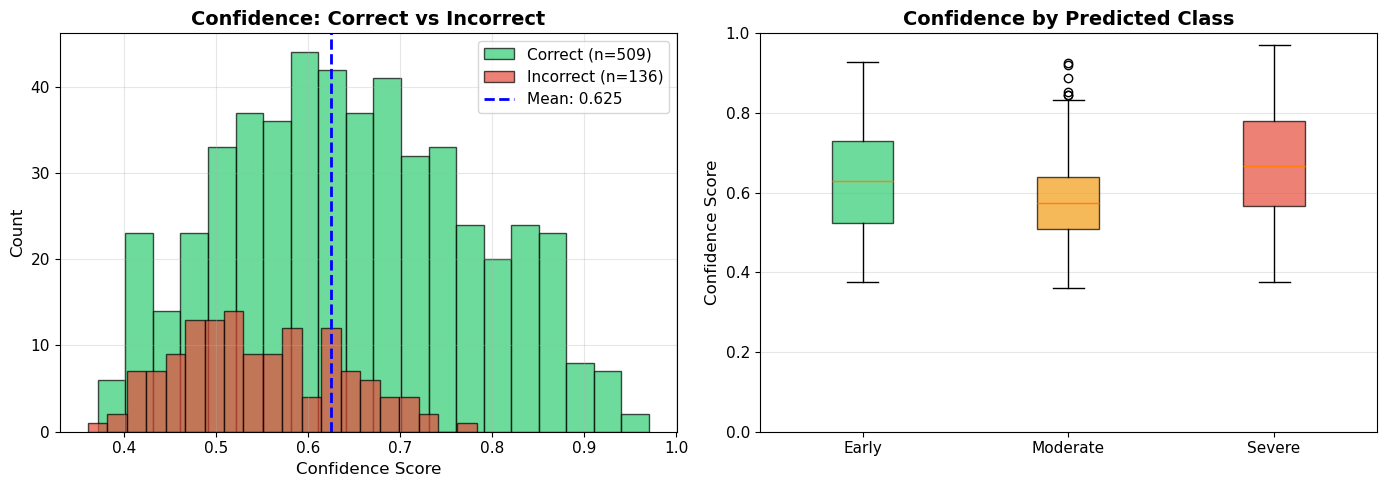


CONFIDENCE STATISTICS
Metric                    Value          
----------------------------------------
Overall Mean              0.6249
Correct Predictions       0.6462
Incorrect Predictions     0.5454

By Class:
  Early        mean=0.632, min=0.375, max=0.929
  Moderate     mean=0.581, min=0.361, max=0.927
  Severe       mean=0.671, min=0.376, max=0.970


In [21]:
# =============================================================================
# CONFIDENCE SCORE ANALYSIS
# =============================================================================

fig = plot_confidence_distribution(
    confidence_scores,
    predicted_classes,
    true_classes,
    class_names,
    save_path='confidence_analysis.png'
)

# Confidence statistics
correct_mask = predicted_classes == true_classes

print()
print("=" * 60)
print("CONFIDENCE STATISTICS")
print("=" * 60)
print(f"{'Metric':<25} {'Value':<15}")
print("-" * 40)
print(f"{'Overall Mean':<25} {np.mean(confidence_scores):.4f}")
print(f"{'Correct Predictions':<25} {np.mean(confidence_scores[correct_mask]):.4f}")
print(f"{'Incorrect Predictions':<25} {np.mean(confidence_scores[~correct_mask]):.4f}")
print()
print("By Class:")
for i, name in enumerate(class_names):
    scores = confidence_scores[predicted_classes == i]
    print(f"  {name:<12} mean={np.mean(scores):.3f}, min={np.min(scores):.3f}, max={np.max(scores):.3f}")
print("=" * 60)

## Section 17: Save Model and Artifacts

Save the trained model in multiple formats for different deployment scenarios:
- H5 format: Standard Keras format
- SavedModel format: For TensorFlow Serving and production deployment
- Training history and metadata for documentation

In [22]:
# =============================================================================
# SAVE MODEL AND ARTIFACTS
# =============================================================================

def save_model_artifacts(model, config, history, val_accuracy, val_loss, output_dir):
    """
    Save model and all related artifacts.
    
    Args:
        model: Trained Keras model
        config: Configuration object
        history: Combined training history
        val_accuracy: Final validation accuracy
        val_loss: Final validation loss
        output_dir: Directory to save artifacts
        
    Returns:
        dict: Paths to saved artifacts
    """
    os.makedirs(output_dir, exist_ok=True)
    
    saved_paths = {}
    
    # 1. Save model in H5 format
    h5_path = os.path.join(output_dir, 'mln_classifier_v3.h5')
    model.save(h5_path)
    saved_paths['model_h5'] = h5_path
    print(f"Saved: {h5_path}")
    
    # 2. Save model in SavedModel format
    savedmodel_path = os.path.join(output_dir, 'mln_classifier_v3_savedmodel')
    model.save(savedmodel_path)
    saved_paths['model_savedmodel'] = savedmodel_path
    print(f"Saved: {savedmodel_path}/")
    
    # 3. Save training history
    history_path = os.path.join(output_dir, 'training_history.pkl')
    with open(history_path, 'wb') as f:
        pickle.dump(history, f)
    saved_paths['history'] = history_path
    print(f"Saved: {history_path}")
    
    # 4. Save class mapping
    class_mapping = {
        'class_indices': val_generator.class_indices,
        'idx_to_class': {v: k for k, v in val_generator.class_indices.items()},
        'class_names': list(val_generator.class_indices.keys())
    }
    mapping_path = os.path.join(output_dir, 'class_mapping.json')
    with open(mapping_path, 'w') as f:
        json.dump(class_mapping, f, indent=2)
    saved_paths['class_mapping'] = mapping_path
    print(f"Saved: {mapping_path}")
    
    # 5. Save model metadata
    metadata = {
        'model_name': 'MLN Severity Classifier v3',
        'base_model': config.BASE_MODEL,
        'input_shape': list(config.INPUT_SHAPE),
        'num_classes': config.NUM_CLASSES,
        'classes': config.CLASS_NAMES,
        'validation_accuracy': float(val_accuracy),
        'validation_loss': float(val_loss),
        'training_config': {
            'batch_size': config.BATCH_SIZE,
            'stage1_epochs': config.EPOCHS_STAGE1,
            'stage2_epochs': config.EPOCHS_STAGE2,
            'stage1_lr': config.LR_STAGE1,
            'stage2_lr': config.LR_STAGE2,
            'unfreeze_layers': config.UNFREEZE_LAYERS,
            'dropout_rate': config.DROPOUT_RATE,
            'l2_regularization': config.L2_REGULARIZATION
        },
        'training_date': pd.Timestamp.now().isoformat()
    }
    metadata_path = os.path.join(output_dir, 'model_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    saved_paths['metadata'] = metadata_path
    print(f"Saved: {metadata_path}")
    
    return saved_paths


# Save all artifacts
print("=" * 60)
print("SAVING MODEL ARTIFACTS")
print("=" * 60)

saved_paths = save_model_artifacts(
    model=model,
    config=config,
    history=combined_history,
    val_accuracy=val_accuracy,
    val_loss=val_loss,
    output_dir=config.OUTPUT_DIR
)

print("=" * 60)
print("ALL ARTIFACTS SAVED SUCCESSFULLY")
print("=" * 60)

SAVING MODEL ARTIFACTS
Saved: ../models/mln_classifier_v3.h5
INFO:tensorflow:Assets written to: ../models/mln_classifier_v3_savedmodel/assets


INFO:tensorflow:Assets written to: ../models/mln_classifier_v3_savedmodel/assets


Saved: ../models/mln_classifier_v3_savedmodel/
Saved: ../models/training_history.pkl
Saved: ../models/class_mapping.json
Saved: ../models/model_metadata.json
ALL ARTIFACTS SAVED SUCCESSFULLY


## Section 18: Final Summary

Comprehensive summary of the training process, results, and next steps.

In [23]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

def print_final_summary(config, val_accuracy, val_loss, combined_history, saved_paths):
    """Print comprehensive summary of training."""
    
    target_achieved = val_accuracy >= 0.85
    
    print("=" * 70)
    print("PHASE 2 CNN TRAINING - FINAL SUMMARY")
    print("=" * 70)
    
    print("""
MODEL ARCHITECTURE
------------------
  Base Model:           {base_model}
  Input Shape:          {input_shape}
  Classifier:           GAP -> BN -> Dropout({dropout}) -> Dense({units}) -> Dropout -> Softmax(3)
  Regularization:       L2({l2}), Dropout, Early Stopping
  Unfrozen Layers:      {unfreeze} (Stage 2)
""".format(
        base_model=config.BASE_MODEL,
        input_shape=f"{config.IMG_SIZE}x{config.IMG_SIZE}x{config.CHANNELS}",
        dropout=config.DROPOUT_RATE,
        units=config.DENSE_UNITS,
        l2=config.L2_REGULARIZATION,
        unfreeze=config.UNFREEZE_LAYERS
    ))
    
    print("""
TRAINING CONFIGURATION
----------------------
  Stage 1 (Frozen):     {s1_epochs} epochs, LR={s1_lr}
  Stage 2 (Fine-tune):  {s2_epochs} epochs, LR={s2_lr}
  Batch Size:           {batch}
  Loss Function:        Focal Loss (gamma={gamma})
  Class Weights:        Applied (balanced)
  Total Epochs:         {total}
""".format(
        s1_epochs=config.EPOCHS_STAGE1,
        s1_lr=config.LR_STAGE1,
        s2_epochs=config.EPOCHS_STAGE2,
        s2_lr=config.LR_STAGE2,
        batch=config.BATCH_SIZE,
        gamma=config.FOCAL_GAMMA,
        total=len(combined_history['accuracy'])
    ))
    
    print("""
RESULTS
-------
  Final Validation Accuracy:  {val_acc:.1f}%
  Final Validation Loss:      {val_loss:.4f}
  Best Validation Accuracy:   {best_acc:.1f}%
  
  Target (85%):               {status}
""".format(
        val_acc=val_accuracy * 100,
        val_loss=val_loss,
        best_acc=max(combined_history['val_accuracy']) * 100,
        status="ACHIEVED" if target_achieved else "Not yet achieved"
    ))
    
    print("""
SAVED ARTIFACTS
---------------""")
    for name, path in saved_paths.items():
        print(f"  {name}: {path}")
    
    if not target_achieved:
        print("""
RECOMMENDATIONS TO IMPROVE ACCURACY
-----------------------------------
  1. Data Quality: Review and correct any mislabeled images
  2. More Data: Collect additional samples, especially for minority classes
  3. Augmentation: Try mixup, cutout, or other advanced augmentations
  4. Architecture: Try EfficientNet-B3 or B4 for more capacity
  5. Ensemble: Combine predictions from multiple models
  6. Unfreeze More: Try unfreezing more layers (e.g., 80-100 layers)
""")
    else:
        print("""
NEXT STEPS
----------
  1. Test on completely unseen data
  2. Export for mobile deployment (TFLite)
  3. Integrate with web/mobile application
  4. Monitor performance in production
""")
    
    print("=" * 70)


# Print final summary
print_final_summary(
    config=config,
    val_accuracy=val_accuracy,
    val_loss=val_loss,
    combined_history=combined_history,
    saved_paths=saved_paths
)

PHASE 2 CNN TRAINING - FINAL SUMMARY

MODEL ARCHITECTURE
------------------
  Base Model:           ResNet50V2
  Input Shape:          224x224x3
  Classifier:           GAP -> BN -> Dropout(0.5) -> Dense(256) -> Dropout -> Softmax(3)
  Regularization:       L2(0.01), Dropout, Early Stopping
  Unfrozen Layers:      50 (Stage 2)


TRAINING CONFIGURATION
----------------------
  Stage 1 (Frozen):     20 epochs, LR=0.001
  Stage 2 (Fine-tune):  40 epochs, LR=1e-05
  Batch Size:           32
  Loss Function:        Focal Loss (gamma=2.0)
  Class Weights:        Applied (balanced)
  Total Epochs:         60


RESULTS
-------
  Final Validation Accuracy:  78.9%
  Final Validation Loss:      0.1607
  Best Validation Accuracy:   78.9%
  
  Target (85%):               Not yet achieved


SAVED ARTIFACTS
---------------
  model_h5: ../models/mln_classifier_v3.h5
  model_savedmodel: ../models/mln_classifier_v3_savedmodel
  history: ../models/training_history.pkl
  class_mapping: ../models/class_map